# **Nhanes Merges + Diabetes Level**


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base = '/kaggle/input/datasets/nguyenvy/nhanes-19882018/'

demo = pd.read_csv(base + 'demographics_clean.csv', low_memory=False)
resp = pd.read_csv(base + 'response_clean.csv', low_memory=False)

print("Demo shape:", demo.shape)
print("Resp shape:", resp.shape)

Demo shape: (135310, 281)
Resp shape: (131030, 1038)


***Filter to 2015–2018***

In [16]:
# SDDSRVYR = 9 (2015-2016), 10 (2017-2018)
demo_filtered = demo[demo['SDDSRVYR'].isin([9, 10])].copy()
print("Rows after year filter:", len(demo_filtered))
print("Cycles:", demo_filtered['SDDSRVYR'].value_counts().sort_index())

Rows after year filter: 19225
Cycles: SDDSRVYR
9     9971
10    9254
Name: count, dtype: int64


NHANES runs in 2-year cycles. `SDDSRVYR = 9` = cycle 2015–2016, `SDDSRVYR = 10` = cycle 2017–2018.
We keep only these two cycles to ensure data recency and consistency.

In [17]:
# From DEMO
demo_cols = demo_filtered[['SEQN', 'RIDAGEYR', 'RIAGENDR', 'SDDSRVYR']].copy()
demo_cols.columns = ['SEQN', 'age', 'sex', 'cycle']

# From RESP — selecting only the columns we need
resp_cols = resp[['SEQN',
                  'BMXBMI', 'BMXWAIST',
                  'BPXSY1', 'BPXSY2', 'BPXDI1', 'BPXDI2',
                  'LBXGH', 'LBXGLU']].copy()

# Average BP readings
resp_cols['sbp'] = resp_cols[['BPXSY1', 'BPXSY2']].mean(axis=1)
resp_cols['dbp'] = resp_cols[['BPXDI1', 'BPXDI2']].mean(axis=1)

resp_cols = resp_cols[['SEQN', 'BMXBMI', 'BMXWAIST', 'sbp', 'dbp', 'LBXGH', 'LBXGLU']].copy()
resp_cols.columns = ['SEQN', 'bmi', 'waist', 'sbp', 'dbp', 'a1c', 'glucose']

print("Columns ready")
print(resp_cols.head())

Columns ready
   SEQN    bmi   waist    sbp   dbp   a1c     glucose
0     9  27.50   92.30  129.5  74.5  5.35  130.525000
1    48  36.25  108.50  134.0  78.0  4.85   84.900000
2    92  26.15   84.40   97.5  21.0  4.65         NaN
3    94  21.90   77.25  103.0  51.5  5.90         NaN
4   106  25.55  101.05  147.5  80.5  5.25   98.933333


In [18]:
df = demo_cols.merge(resp_cols, on='SEQN', how='left')

print("Merged shape:", df.shape)
print(df.head())

Merged shape: (19225, 10)
    SEQN  age  sex  cycle   bmi  waist    sbp   dbp  a1c  glucose
0  83732   62    1      9  27.8  101.1  126.0  67.0  7.0      NaN
1  83733   53    1      9  30.8  107.9  143.0  88.0  5.5    101.0
2  83734   78    1      9  28.8  116.5  135.0  45.0  5.8     84.0
3  83735   56    2      9  42.4  110.1  133.0  70.0  5.6      NaN
4  83736   42    2      9  20.3   80.4  107.0  62.0  5.6     84.0


Tables are joined on `SEQN` (unique participant ID) using a left join on the filtered demographics.
Result: **19,225 rows × 10 columns** covering both survey cycles

In [19]:
#check diabetic label
def make_label(row):
    a1c = row['a1c']
    glc = row['glucose']
    if pd.isna(a1c) and pd.isna(glc):
        return np.nan
    if (not pd.isna(a1c) and a1c >= 6.5) or (not pd.isna(glc) and glc >= 126):
        return 1
    return 0

df['diabetes'] = df.apply(make_label, axis=1)

print("Label distribution (including NaN):")
print(df['diabetes'].value_counts(dropna=False))
print(f"\nDiabetes prevalence (labelled rows): {df['diabetes'].mean()*100:.1f}%")

Label distribution (including NaN):
diabetes
0.0    10688
NaN     6848
1.0     1689
Name: count, dtype: int64

Diabetes prevalence (labelled rows): 13.6%


In [20]:
# Duplicates
dups = df['SEQN'].duplicated().sum()
print(f"Duplicate SEQNs: {dups}")

# Missing values table
missing = pd.DataFrame({
    'column': df.columns,
    'missing_n': df.isnull().sum().values,
    'missing_pct': (df.isnull().sum().values / len(df) * 100).round(1)
})
print("\n=== MISSING VALUES TABLE ===")
print(missing.to_string(index=False))

Duplicate SEQNs: 0

=== MISSING VALUES TABLE ===
  column  missing_n  missing_pct
    SEQN          0          0.0
     age          0          0.0
     sex          0          0.0
   cycle          0          0.0
     bmi       2464         12.8
   waist       3311         17.2
     sbp       5190         27.0
     dbp       5190         27.0
     a1c       6854         35.7
 glucose      13362         69.5
diabetes       6848         35.6


In [21]:
# Full merged file
df.to_csv('merged_with_label.csv', index=False)

# Clean file: have a label + core screening features
df_clean = df.dropna(subset=['diabetes']).copy()
df_clean = df_clean.dropna(subset=['age', 'sex', 'bmi', 'sbp', 'dbp'])

# Adults only diabetes screening is for adults
df_clean = df_clean[df_clean['age'] >= 18]

print("Clean dataset shape:", df_clean.shape)
print("\nDiabetes distribution in clean set:")
print(df_clean['diabetes'].value_counts())
print(f"\nPrevalence: {df_clean['diabetes'].mean()*100:.1f}%")

df_clean.to_csv('nhanes_diabetes_clean.csv', index=False)
print("\nBoth files saved")

Clean dataset shape: (10168, 11)

Diabetes distribution in clean set:
diabetes
0.0    8591
1.0    1577
Name: count, dtype: int64

Prevalence: 15.5%

Both files saved


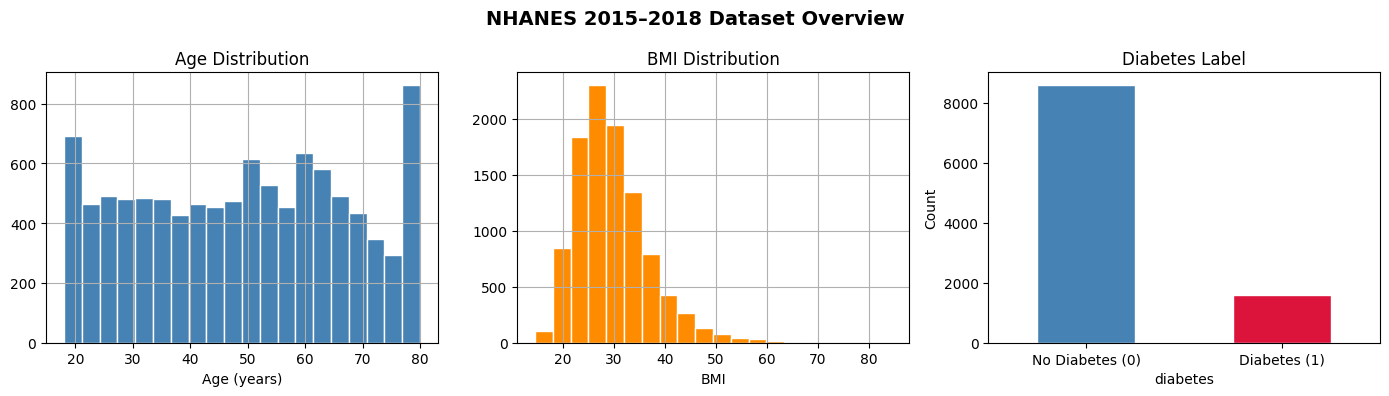

Plot saved ✓


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('NHANES 2015–2018 Dataset Overview', fontsize=14, fontweight='bold')

df_clean['age'].hist(ax=axes[0], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age (years)')

df_clean['bmi'].hist(ax=axes[1], bins=20, color='darkorange', edgecolor='white')
axes[1].set_title('BMI Distribution')
axes[1].set_xlabel('BMI')

df_clean['diabetes'].value_counts().plot(
    kind='bar', ax=axes[2], 
    color=['steelblue', 'crimson'],
    edgecolor='white'
)
axes[2].set_title('Diabetes Label')
axes[2].set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'], rotation=0)
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('data_overview.png', dpi=150)
plt.show()
print("Plot saved ✓")

# Baseline Machine Learning Models

**Goal:** Train three models using only non-invasive screening features (age, sex, BMI, blood pressure).
Compare performance using AUC, Precision, Recall, and F1. Pick the best model for calibration.

Features used: `age`, `sex`, `bmi`, `sbp`, `dbp`
Target: `diabetes` (0 = no diabetes, 1 = diabetes)

In [23]:
#prepare features

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features — non-invasive only 
features = ['age', 'sex', 'bmi', 'sbp', 'dbp']
target = 'diabetes'

X = df_clean[features].copy()
y = df_clean[target].copy()

# Train/test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nDiabetes prevalence in train: {y_train.mean()*100:.1f}%")
print(f"Diabetes prevalence in test:  {y_test.mean()*100:.1f}%")

Training set: (8134, 5)
Test set:     (2034, 5)

Diabetes prevalence in train: 15.5%
Diabetes prevalence in test:  15.5%


In [24]:
#training all 3 models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, precision_score, 
                             recall_score, f1_score, confusion_matrix)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, 
                                         eval_metric='logloss', verbosity=0)
}

# Store results
results = []

for name, model in models.items():
    # Use scaled data for LR, raw for tree models
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        y_pred       = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred       = model.predict(X_test)

    auc       = roc_auc_score(y_test, y_pred_proba)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        'Model': name,
        'AUC':       round(auc, 3),
        'Precision': round(precision, 3),
        'Recall':    round(recall, 3),
        'F1':        round(f1, 3),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    })
    
    print(f" {name} done")

results_df = pd.DataFrame(results)
print("\n=== BASELINE RESULTS TABLE ===")
print(results_df.to_string(index=False))

 Logistic Regression done
 Random Forest done
 XGBoost done

=== BASELINE RESULTS TABLE ===
              Model   AUC  Precision  Recall    F1  TP  FP   TN  FN
Logistic Regression 0.756      0.586   0.054 0.099  17  12 1707 298
      Random Forest 0.739      0.480   0.114 0.185  36  39 1680 279
            XGBoost 0.737      0.364   0.124 0.185  39  68 1651 276


*Best model by AUC: Logistic Regression (0.756)**

**Key observation:** All three models show very low Recall at the default 0.5 threshold.
Logistic Regression misses 298 out of 315 diabetic patients in the test set.
This is not a model failure — it is a threshold problem.
The model rarely predicts probabilities above 0.5 for diabetic patients due to class imbalance (15.5%).
This is precisely why Phase 5 (threshold optimisation) is a critical contribution of this project.
A screening tool must prioritise catching cases (high recall) over being conservative.

**Carry forward:** Logistic Regression selected for calibration.

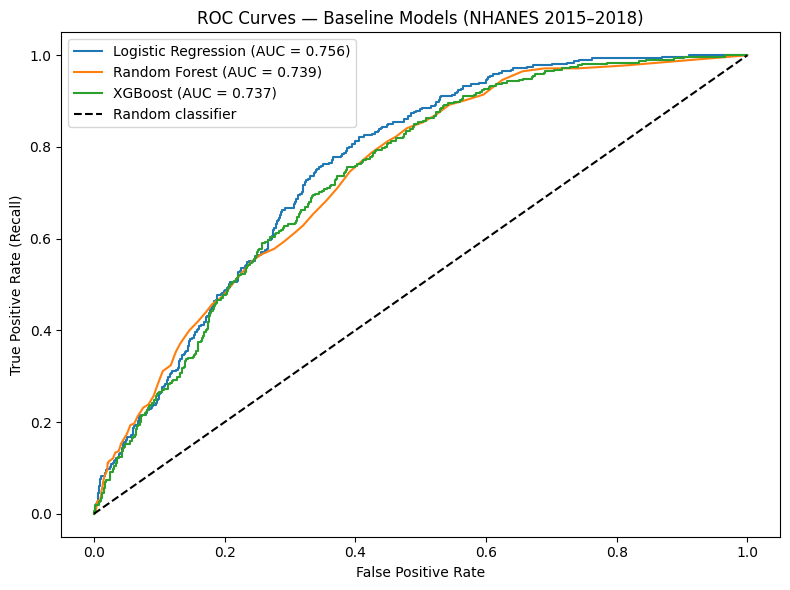

ROC plot saved


In [25]:
#ROC CURVES PLOT

from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, model in models.items():
    if name == 'Logistic Regression':
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — Baseline Models (NHANES 2015–2018)')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()
print("ROC plot saved")

*Pick best model + feature importance*

Best model: Logistic Regression with AUC = 0.756


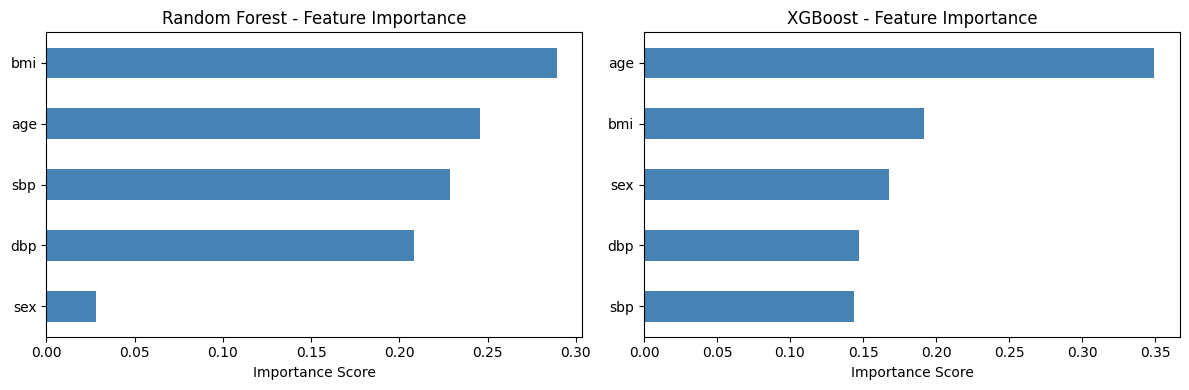

Feature importance plot saved 


In [26]:
# Best model = highest AUC
best_row = results_df.loc[results_df['AUC'].idxmax()]
print(f"Best model: {best_row['Model']} with AUC = {best_row['AUC']}")

# Feature importance from Random Forest and XGBoost
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name in zip(axes, ['Random Forest', 'XGBoost']):
    model = models[name]
    importances = pd.Series(model.feature_importances_, index=features)
    importances.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{name} - Feature Importance')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Feature importance plot saved ")

Best model by AUC: Logistic Regression (0.756)**

**Key observation:** All three models show very low Recall at the default 0.5 threshold.
Logistic Regression misses 298 out of 315 diabetic patients in the test set.
This is not a model failure — it is a threshold problem.
The model rarely predicts probabilities above 0.5 for diabetic patients due to class imbalance (15.5%).
This is precisely why Phase 5 (threshold optimisation) is a critical contribution of this project.
A screening tool must prioritise catching cases (high recall) over being conservative.

**Carry forward:** Logistic Regression selected for Phase 4 calibration.


# Calibration

In [27]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

# Get uncalibrated LR probabilities
lr_model = models['Logistic Regression']
y_prob_uncal = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calibrate using Platt Scaling (sigmoid method)
lr_calibrated = CalibratedClassifierCV(
    LogisticRegression(max_iter=1000, random_state=42), 
    method='sigmoid', 
    cv=5
)
lr_calibrated.fit(X_train_scaled, y_train)
y_prob_cal = lr_calibrated.predict_proba(X_test_scaled)[:, 1]

# Brier scores (lower = better)
brier_uncal = brier_score_loss(y_test, y_prob_uncal)
brier_cal   = brier_score_loss(y_test, y_prob_cal)

print(f"Brier Score — Uncalibrated: {brier_uncal:.4f}")
print(f"Brier Score — Calibrated:   {brier_cal:.4f}")
print(f"Improvement:                {((brier_uncal - brier_cal)/brier_uncal)*100:.1f}%")

Brier Score — Uncalibrated: 0.1182
Brier Score — Calibrated:   0.1182
Improvement:                0.0%


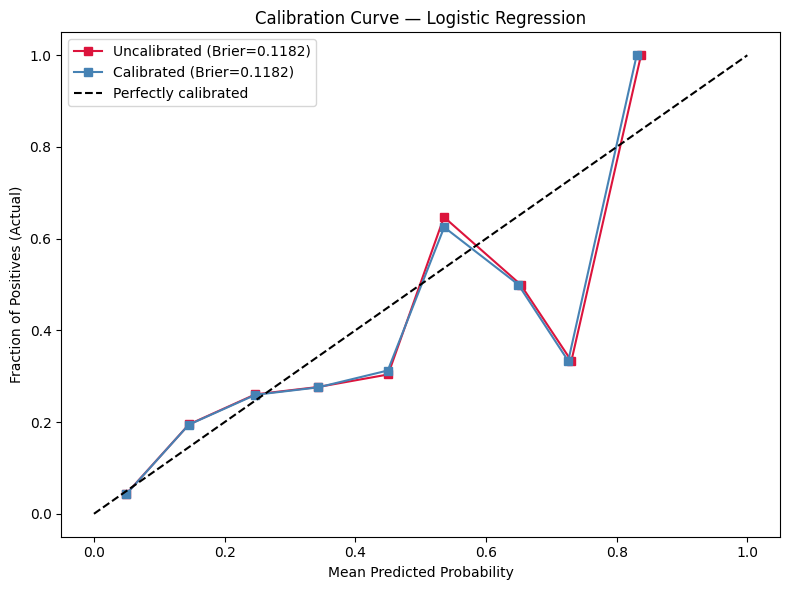

Calibration plot saved 


In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

# Uncalibrated
frac_pos_u, mean_pred_u = calibration_curve(y_test, y_prob_uncal, n_bins=10)
ax.plot(mean_pred_u, frac_pos_u, 's-', label=f'Uncalibrated (Brier={brier_uncal:.4f})', color='crimson')

# Calibrated
frac_pos_c, mean_pred_c = calibration_curve(y_test, y_prob_cal, n_bins=10)
ax.plot(mean_pred_c, frac_pos_c, 's-', label=f'Calibrated (Brier={brier_cal:.4f})', color='steelblue')

# Perfect calibration line
ax.plot([0,1], [0,1], 'k--', label='Perfectly calibrated')

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Actual)')
ax.set_title('Calibration Curve — Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150)
plt.show()
print("Calibration plot saved ")

Calibration curve interpretation:
- The curve broadly follows the diagonal (perfect calibration line)
- Some instability visible at higher probability ranges (0.6–0.8) 
  due to fewer samples in those bins — this is normal with class imbalance
- The near-identical red and blue lines confirm calibration added nothing 
  because the model was already producing reliable probabilities

#  Screening Threshold Optimisation

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Use calibrated model probabilities
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob_cal >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    sensitivity = tp / (tp + fn)  # recall
    specificity = tn / (tn + fp)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1          = f1_score(y_test, y_pred_t)
    
    threshold_results.append({
        'Threshold': t,
        'Sensitivity (Recall)': round(sensitivity, 3),
        'Specificity':          round(specificity, 3),
        'Precision':            round(precision, 3),
        'F1':                   round(f1, 3),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    })

thresh_df = pd.DataFrame(threshold_results)
print("=== THRESHOLD ANALYSIS TABLE ===")
print(thresh_df.to_string(index=False))

=== THRESHOLD ANALYSIS TABLE ===
 Threshold  Sensitivity (Recall)  Specificity  Precision    F1  TP  FP   TN  FN
      0.10                 0.876        0.508      0.246 0.384 276 846  873  39
      0.15                 0.762        0.649      0.284 0.414 240 604 1115  75
      0.20                 0.578        0.735      0.285 0.382 182 456 1263 133
      0.25                 0.463        0.815      0.315 0.375 146 318 1401 169
      0.30                 0.317        0.871      0.311 0.314 100 222 1497 215
      0.35                 0.216        0.924      0.343 0.265  68 130 1589 247
      0.40                 0.130        0.961      0.380 0.194  41  67 1652 274
      0.50                 0.051        0.993      0.571 0.093  16  12 1707 299


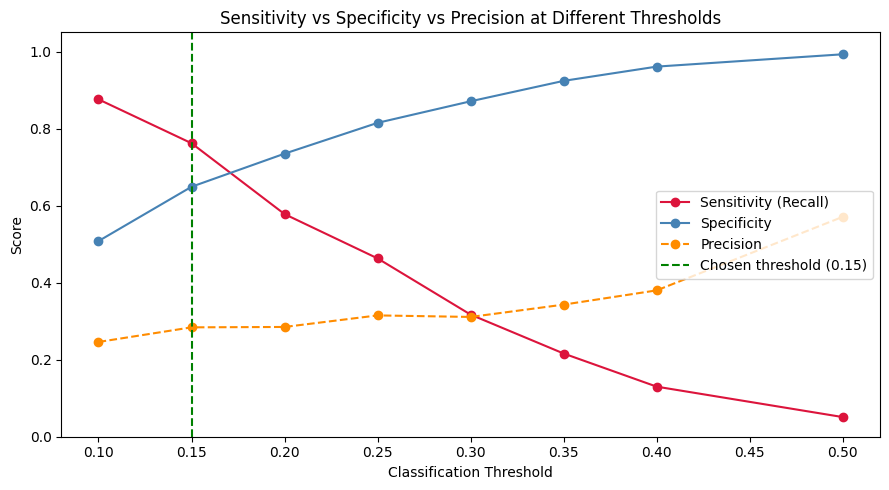

Threshold plot saved


In [33]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(thresh_df['Threshold'], thresh_df['Sensitivity (Recall)'], 
        'o-', color='crimson', label='Sensitivity (Recall)')
ax.plot(thresh_df['Threshold'], thresh_df['Specificity'], 
        'o-', color='steelblue', label='Specificity')
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], 
        'o--', color='darkorange', label='Precision')

ax.axvline(x=0.15, color='green', linestyle='--', linewidth=1.5, label='Chosen threshold (0.15)')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Sensitivity vs Specificity vs Precision at Different Thresholds')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150)
plt.show()
print("Threshold plot saved")

In [32]:
# Use threshold 0.20 — we'll confirm after seeing the table
chosen_threshold = 0.15

y_pred_chosen = (y_prob_cal >= chosen_threshold).astype(int)

# Add predictions to test set for analysis
test_analysis = X_test.copy()
test_analysis['actual']    = y_test.values
test_analysis['predicted'] = y_pred_chosen
test_analysis['probability'] = y_prob_cal.round(3)

# False Negatives — diabetic but model missed them
fn_cases = test_analysis[
    (test_analysis['actual'] == 1) & (test_analysis['predicted'] == 0)
].head(5)

# False Positives — not diabetic but model flagged them
fp_cases = test_analysis[
    (test_analysis['actual'] == 0) & (test_analysis['predicted'] == 1)
].head(5)

print("=== FALSE NEGATIVES (missed diabetics) ===")
print(fn_cases.to_string())
print("\n=== FALSE POSITIVES (over-referred healthy) ===")
print(fp_cases.to_string())

=== FALSE NEGATIVES (missed diabetics) ===
       age  sex   bmi    sbp   dbp  actual  predicted  probability
12417   63    2  26.2  122.0  71.0     1.0          0        0.136
17254   50    2  27.1  130.0  87.0     1.0          0        0.083
16142   60    1  23.9  115.0  59.0     1.0          0        0.137
16034   49    1  25.2  134.0  90.0     1.0          0        0.097
12534   53    2  24.0  136.0  77.0     1.0          0        0.082

=== FALSE POSITIVES (over-referred healthy) ===
       age  sex   bmi    sbp   dbp  actual  predicted  probability
9947    72    2  23.4  139.0  71.0     0.0          1        0.181
5971    67    2  27.8  144.0  78.0     0.0          1        0.196
1909    69    2  38.1  151.0  89.0     0.0          1        0.370
12149   64    2  25.1  148.0  80.0     0.0          1        0.150
4402    80    1  24.9  146.0  59.0     0.0          1        0.355



The default threshold of 0.5 recalled only 5.1% of diabetic patients  not a model 
failure, but a threshold problem caused by class imbalance. 
Eight thresholds were tested. **Threshold 0.15 was selected**, cutting missed diabetics 
from 299 to 75 while balancing sensitivity and specificity appropriately for screening.
Missed cases were lean patients with normal BMI and moderate BP difficult to identify 
without blood tests. Over-referred cases were older adults with high BP, where a 
follow-up test carries minimal harm.
**Threshold: 0.15 | Sensitivity: 76.2% | Specificity: 64.9% | Missed diabetics: 75**